In [21]:
!pip install arxiv

import arxiv
import pandas as pd

# Cómo construir una ecuación de búsqueda para arXiv

Una **ecuación de búsqueda en arXiv** es una cadena de texto que combina palabras clave con operadores lógicos para localizar papers relevantes de manera precisa.

## 1. Operadores booleanos

### **`AND`**
El documento debe contener *ambos* términos.
quantum AND "partial differential equation"

### **`OR`**
El documento puede contener uno u otro término.
PDE OR "differential equations"

### **`AND NOT`**
Incluye un término y excluye otro.
quantum AND NOT chemistry

## 2. Búsquedas exactas con comillas
Usa comillas para buscar frases completas:
"quantum neural network"

Sin comillas se busca cada palabra por separado.

## 3. Agrupar ideas con paréntesis

Sirve para combinar varios conceptos:
("quantum neural network" OR "quantum machine learning")
AND
("partial differential equation" OR PDE)

## 4. Buscar en categorías específicas de arXiv

ArXiv clasifica los papers por áreas. Para buscar solo dentro de una categoría:

cat:quant-ph
cat:cs.LG
cat:math.AP

Ejemplo:
("quantum neural" AND PDE) AND cat:quant-ph

## 5. Buscar por autor
au:"John Preskill"

## 6. Buscar por fechas
submittedDate:[2020 TO 2025]

Ejemplo combinado: "quantum neural network" AND submittedDate:[2021 TO 2025]

## 7. Ejemplos listos de ecuaciones de búsqueda (tema: QNN + PDE)

### **Búsqueda general**
"quantum neural" AND PDE

### **Búsqueda amplia**
("quantum neural network" OR "quantum machine learning")
AND
("partial differential equation" OR PDE)

### **Solo categoría Quantum Physics**
("quantum neural" AND PDE) AND cat:quant-ph

### **PINNs cuánticas**
("quantum" AND "physics-informed neural network") AND cat:cs.LG

### **Con sinónimos adicionales**
("quantum neural" OR "quantum circuit learning")
AND
("partial differential equation" OR PDE OR "differential equation")


## 8. Pasos para construir tu ecuación de búsqueda

1. **Define tu tema.**
2. **Elige palabras clave.**
3. **Identifica sinónimos.**
4. **Combina usando `AND` y `OR`.**
5. **(Opcional) Restringe por categoría (`cat:`).**

In [52]:
# --- CONSULTAS OPTIMIZADAS PARA RADIOASTRONOMÍA ---
queries = [
    # 1. Interferometría y técnicas avanzadas
    '"radio interferometry" AND ("image reconstruction" OR "aperture synthesis")',
    
    # 2. Procesamiento de señales con ML
    '"radio telescope" AND ("machine learning" OR "deep learning") AND ("signal processing" OR "data processing")',
    
    # 3. Observaciones solares específicas
    '"solar radio emission" AND ("microwave" OR "millimeter wave" OR "ku band")',
    
    # 4. Big Data en radioastronomía
    '"radio astronomy" AND ("big data" OR "data mining" OR "data pipeline")',
    
    # 5. Calibración y reducción de datos
    '"radio astronomy" AND ("calibration" OR "data reduction" OR "flagging")',
    
    # 6. Técnicas de observación modernas
    '"phased array" AND ("radio telescope" OR "radio astronomy")',
    
    # 7. Procesamiento de imágenes astronómicas
    '"radio astronomy imaging" AND ("deconvolution" OR "CLEAN algorithm" OR "compressed sensing")',
    
    # 8. Análisis espectral y espectroscopia
    '"radio spectroscopy" AND ("molecular lines" OR "spectral line") AND "astronomy"',
    
    # 9. Técnicas de bajo ruido y RFI
    '"radio frequency interference" AND ("mitigation" OR "RFI removal") AND "astronomy"',
    
    # 10. Arreglos de telescopios y VLBI
    '"very long baseline interferometry" OR "VLBI" AND ("data processing" OR "correlation")',
    
    # 11. Instrumentación y tecnología
    '"radio telescope receiver" AND ("cryogenic" OR "low noise amplifier" OR "feed design")'
]

# Para buscar también en español/inglés, podríamos añadir:
# '"radiotelescopio" OR "radio telescope"' como consulta adicional si se desea

max_results = 200

data = []

for q in queries:
    print(f"Buscando: {q}")
    search = arxiv.Search(
        query=q,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.SubmittedDate
    )

    for paper in search.results():
        data.append({
            "title": paper.title,
            "authors": [a.name for a in paper.authors],
            "abstract": paper.summary,
            "arxiv_id": paper.get_short_id(),
            "category": paper.primary_category,
            "date": paper.published,
            "pdf_url": paper.pdf_url,
            "query_used": q
        })

# --- CREAR BASE DE DATOS ---
df = pd.DataFrame(data)

# Eliminar duplicados por ID
df = df.drop_duplicates(subset="arxiv_id")

df.to_csv("arxiv_Radio_Astronomy.csv", index=False)
    
print("Base de datos creada con", len(df), "papers.")
df.head()


Buscando: "radio interferometry" AND ("image reconstruction" OR "aperture synthesis")
Buscando: "radio telescope" AND ("machine learning" OR "deep learning") AND ("signal processing" OR "data processing")
Buscando: "solar radio emission" AND ("microwave" OR "millimeter wave" OR "ku band")
Buscando: "radio astronomy" AND ("big data" OR "data mining" OR "data pipeline")
Buscando: "radio astronomy" AND ("calibration" OR "data reduction" OR "flagging")
Buscando: "phased array" AND ("radio telescope" OR "radio astronomy")
Buscando: "radio astronomy imaging" AND ("deconvolution" OR "CLEAN algorithm" OR "compressed sensing")
Buscando: "radio spectroscopy" AND ("molecular lines" OR "spectral line") AND "astronomy"
Buscando: "radio frequency interference" AND ("mitigation" OR "RFI removal") AND "astronomy"
Buscando: "very long baseline interferometry" OR "VLBI" AND ("data processing" OR "correlation")
Buscando: "radio telescope receiver" AND ("cryogenic" OR "low noise amplifier" OR "feed design

,title,authors,abstract,arxiv_id,category,date,pdf_url,query_used
0,Bayesian polarization calibration and imaging ...,"[Jong-Seo Kim, Jakob Roth, Jongho Park, Jack D...",Extracting polarimetric information from very ...,2511.16556v1,astro-ph.IM,2025-11-20 17:10:06+00:00,https://arxiv.org/pdf/2511.16556v1,"""radio interferometry"" AND (""image reconstruct..."
1,HyperAIRI: a plug-and-play algorithm for preci...,"[Chao Tang, Arwa Dabbech, Adrian Jackson, Yves...",The next-generation radio-interferometric (RI)...,2510.15198v1,astro-ph.IM,2025-10-16 23:49:20+00:00,https://arxiv.org/pdf/2510.15198v1,"""radio interferometry"" AND (""image reconstruct..."
2,Generative imaging for radio interferometry wi...,"[Matthijs Mars, Tobías I. Liaudat, Jessica J. ...",With the rise of large radio interferometric t...,2507.21270v1,astro-ph.IM,2025-07-28 18:52:07+00:00,https://arxiv.org/pdf/2507.21270v1,"""radio interferometry"" AND (""image reconstruct..."
3,How to make CLEAN variants faster? Using clust...,"[Hendrik Müller, Sanjay Bhatnagar]","Deconvolution, imaging and calibration of data...",2504.16058v1,astro-ph.IM,2025-04-22 17:33:55+00:00,https://arxiv.org/pdf/2504.16058v1,"""radio interferometry"" AND (""image reconstruct..."
4,Toward a Robust R2D2 Paradigm for Radio-interf...,"[Amir Aghabiglou, Chung San Chu, Chao Tang, Ar...",The R2D2 Deep Neural Network (DNN) series was ...,2503.02554v2,astro-ph.IM,2025-03-04 12:26:45+00:00,https://arxiv.org/pdf/2503.02554v2,"""radio interferometry"" AND (""image reconstruct..."


# **TALLER PLN**

Cada estudiante o grupo entregará:
1. Tema preseleccionado de investigación para tesis.
2. Dataset con ≥ 50 abstracts de arXiv.
3. Limpieza básica del texto.
4. Matriz TF-IDF y otros vectorizadores.
6. Clustering simple (K-means por lo menos, pueden intentar con otros algoritmos de clustering no hay límite).
7. Visualización 2D (opcional).
8. Interpretación de los clusters.
9. Conclusión: ¿qué subtema parece más prometedor para su tesis?

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset
df = pd.read_csv('arxiv_Radio_Astronomy.csv')
print(f"Dataset cargado: {df.shape[0]} papers")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
print(df.head())

Dataset cargado: 1039 papers

Columnas: ['title', 'authors', 'abstract', 'arxiv_id', 'category', 'date', 'pdf_url', 'query_used']

Primeras filas:
                                               title  \
0  Bayesian polarization calibration and imaging ...   
1  HyperAIRI: a plug-and-play algorithm for preci...   
2  Generative imaging for radio interferometry wi...   
3  How to make CLEAN variants faster? Using clust...   
4  Toward a Robust R2D2 Paradigm for Radio-interf...   

                                             authors  \
0  ['Jong-Seo Kim', 'Jakob Roth', 'Jongho Park', ...   
1  ['Chao Tang', 'Arwa Dabbech', 'Adrian Jackson'...   
2  ['Matthijs Mars', 'Tobías I. Liaudat', 'Jessic...   
3             ['Hendrik Müller', 'Sanjay Bhatnagar']   
4  ['Amir Aghabiglou', 'Chung San Chu', 'Chao Tan...   

                                            abstract      arxiv_id  \
0  Extracting polarimetric information from very ...  2511.16556v1   
1  The next-generation radio-interferom

In [53]:
print("ANÁLISIS EXPLORATORIO DE DATOS (EDA)")

# Estadísticas del dataset
print("\n ESTADÍSTICAS GENERALES DEL DATASET:")
print(f"Total de papers: {len(df)}")
print(f"Rango temporal: {df['date'].min()} a {df['date'].max()}")
print(f"Años cubiertos: {df['date'].dt.year.max() - df['date'].dt.year.min() + 1}")
print(f"\nLongitud de abstracts:")
print(f"  Mínimo: {df['abstract'].str.len().min()} caracteres")
print(f"  Máximo: {df['abstract'].str.len().max()} caracteres")
print(f"  Promedio: {df['abstract'].str.len().mean():.0f} caracteres")
print(f"  Mediana: {df['abstract'].str.len().median():.0f} caracteres")

print(f"\nValores faltantes:")
print(df.isnull().sum())

print(f"\nCategorías de arXiv representadas: {df['category'].nunique()}")
print(f"\nTop 15 categorías más frecuentes:")
category_counts = df['category'].value_counts().head(15)
for cat, count in category_counts.items():
    print(f"  {cat}: {count} papers ({count/len(df)*100:.1f}%)")

ANÁLISIS EXPLORATORIO DE DATOS (EDA)

 ESTADÍSTICAS GENERALES DEL DATASET:
Total de papers: 1039
Rango temporal: 1994-08-29 10:17:16+00:00 a 2025-12-03 07:30:15+00:00
Años cubiertos: 32

Longitud de abstracts:
  Mínimo: 323 caracteres
  Máximo: 3075 caracteres
  Promedio: 1400 caracteres
  Mediana: 1445 caracteres

Valores faltantes:
title         0
authors       0
abstract      0
arxiv_id      0
category      0
date          0
pdf_url       0
query_used    0
dtype: int64

Categorías de arXiv representadas: 29

Top 15 categorías más frecuentes:
  astro-ph.IM: 467 papers (44.9%)
  astro-ph.HE: 158 papers (15.2%)
  astro-ph.SR: 127 papers (12.2%)
  astro-ph.GA: 115 papers (11.1%)
  astro-ph.CO: 44 papers (4.2%)
  astro-ph: 41 papers (3.9%)
  astro-ph.EP: 18 papers (1.7%)
  gr-qc: 11 papers (1.1%)
  eess.SP: 8 papers (0.8%)
  cs.DC: 6 papers (0.6%)
  eess.IV: 5 papers (0.5%)
  quant-ph: 5 papers (0.5%)
  cs.CV: 3 papers (0.3%)
  cs.LG: 3 papers (0.3%)
  physics.app-ph: 3 papers (0.3%)



ANÁLISIS TEMPORAL

Papers por año:
  1994: 1 papers
  1996: 1 papers
  2000: 4 papers
  2001: 3 papers
  2002: 2 papers
  2003: 6 papers
  2004: 4 papers
  2005: 3 papers
  2006: 3 papers
  2007: 2 papers
  2008: 12 papers
  2009: 15 papers
  2010: 10 papers
  2011: 24 papers
  2012: 19 papers
  2013: 23 papers
  2014: 24 papers
  2015: 24 papers
  2016: 38 papers
  2017: 39 papers
  2018: 46 papers
  2019: 76 papers
  2020: 58 papers
  2021: 63 papers
  2022: 82 papers
  2023: 65 papers
  2024: 176 papers
  2025: 216 papers


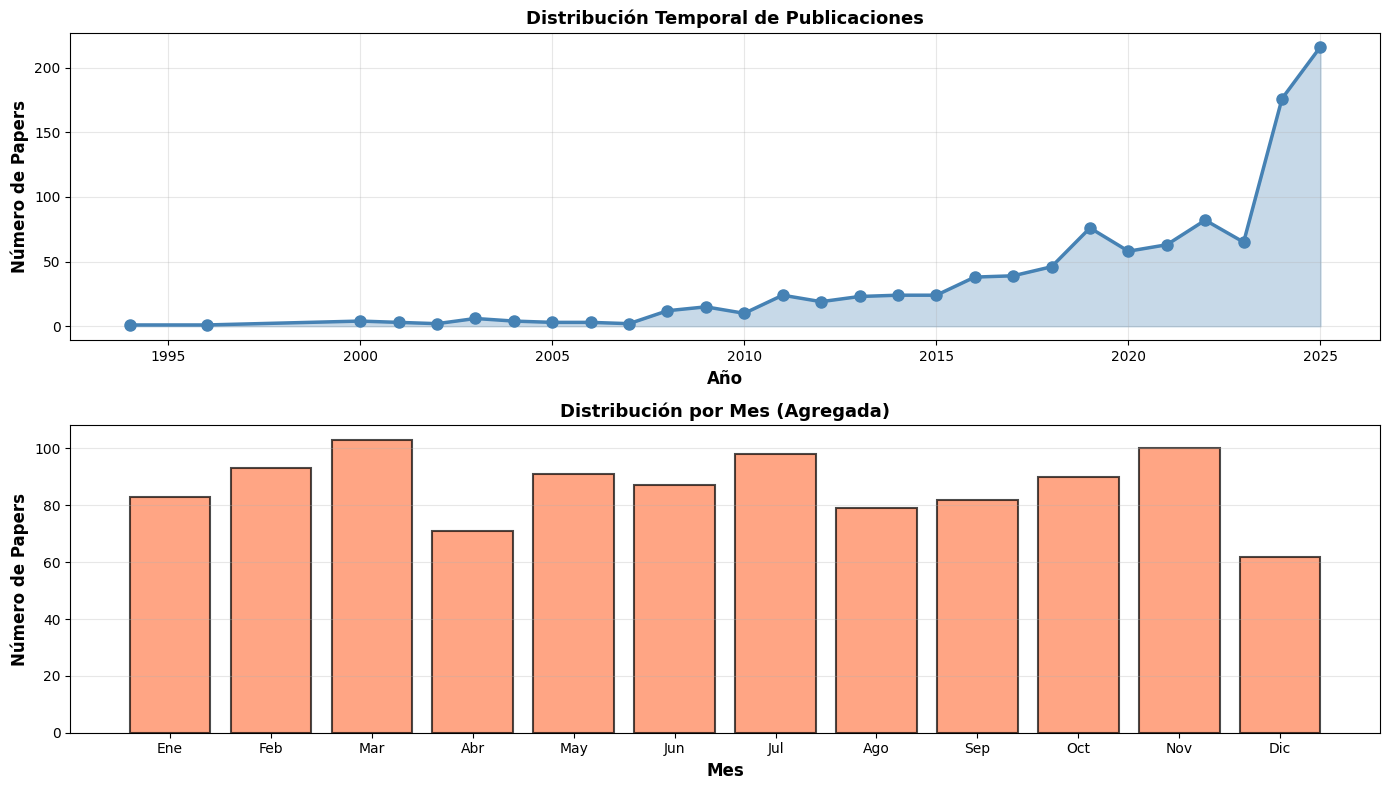


✓ Gráficos temporales guardados en 'eda_temporal_distribution.png'


In [24]:
print("\n" + "="*70)
print("ANÁLISIS TEMPORAL")
print("="*70)

# Convertir fechas
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Estadísticas por año
yearly_counts = df.groupby('year').size()
print("\nPapers por año:")
for year, count in yearly_counts.items():
    print(f"  {year}: {count} papers")

# Visualizar distribución temporal
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Gráfico de línea - Papers por año
axes[0].plot(yearly_counts.index, yearly_counts.values, 'o-', linewidth=2.5, markersize=8, color='steelblue')
axes[0].fill_between(yearly_counts.index, yearly_counts.values, alpha=0.3, color='steelblue')
axes[0].set_xlabel('Año', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Número de Papers', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución Temporal de Publicaciones', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Gráfico de barras - Papers por mes (agregado)
monthly_counts = df.groupby('month').size()
months = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
axes[1].bar(monthly_counts.index, monthly_counts.values, color='coral', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Mes', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Número de Papers', fontsize=12, fontweight='bold')
axes[1].set_title('Distribución por Mes (Agregada)', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(months)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_temporal_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Gráficos temporales guardados en 'eda_temporal_distribution.png'")


ANÁLISIS DE CATEGORÍAS


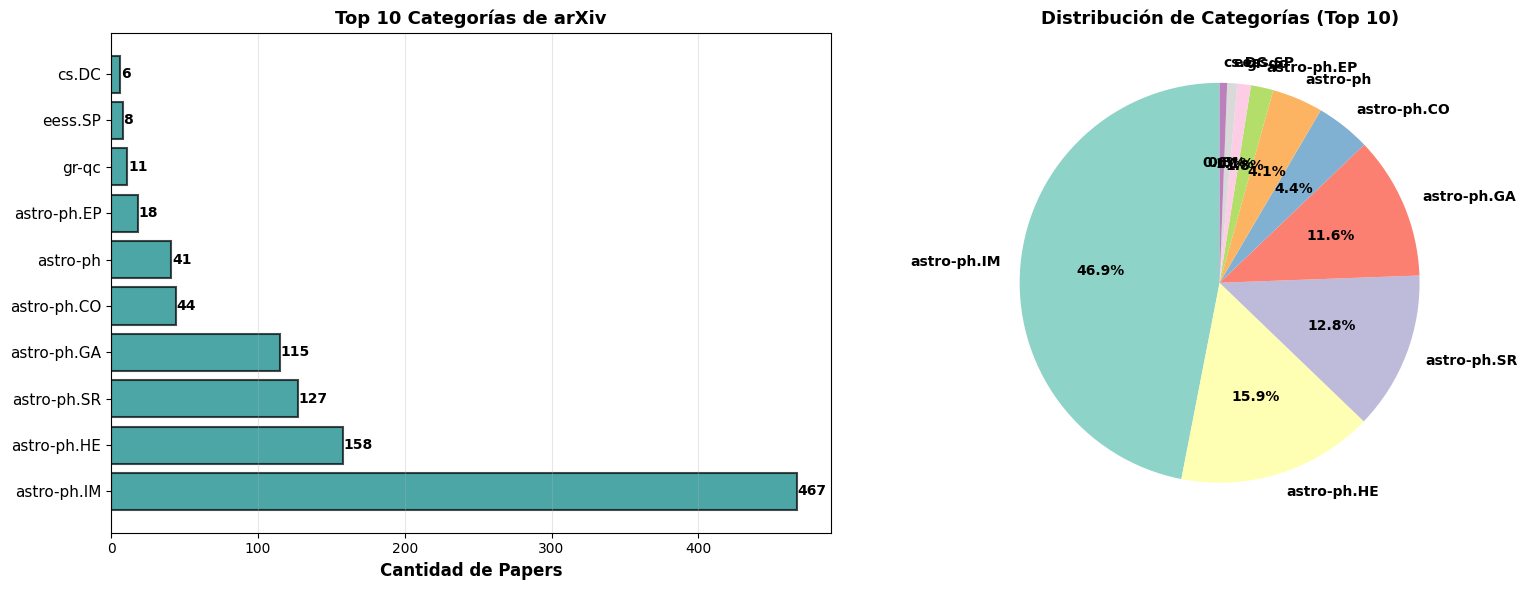


✓ Gráficos de categorías guardados en 'eda_categories.png'


In [26]:
print("\n" + "="*70)
print("ANÁLISIS DE CATEGORÍAS")
print("="*70)

# Top categorías
top_categories = df['category'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras horizontal
axes[0].barh(range(len(top_categories)), top_categories.values, color='teal', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(top_categories)))
axes[0].set_yticklabels(top_categories.index, fontsize=11)
axes[0].set_xlabel('Cantidad de Papers', fontsize=12, fontweight='bold')
axes[0].set_title('Top 10 Categorías de arXiv', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Agregar valores en las barras
for i, v in enumerate(top_categories.values):
    axes[0].text(v + 0.5, i, str(v), va='center', fontweight='bold')

# Pie chart
colors = plt.cm.Set3(range(len(top_categories)))
axes[1].pie(top_categories.values, labels=top_categories.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[1].set_title('Distribución de Categorías (Top 10)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_categories.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Gráficos de categorías guardados en 'eda_categories.png'")


ANÁLISIS DE ABSTRACTS

Estadísticas de longitud de abstracts:

Abstracts originales:
count    1039.000000
mean     1399.854668
std       366.643142
min       323.000000
25%      1143.000000
50%      1445.000000
75%      1692.500000
max      3075.000000
Name: abstract_length_raw, dtype: float64

Abstracts limpios:
count    1039.000000
mean     1336.395573
std       348.922968
min       315.000000
25%      1089.500000
50%      1375.000000
75%      1611.000000
max      2835.000000
Name: abstract_length_clean, dtype: float64

Abstracts procesados:
count    1039.000000
mean     1020.261790
std       270.445078
min       260.000000
25%       843.000000
50%      1050.000000
75%      1227.000000
max      2030.000000
Name: abstract_length_processed, dtype: float64


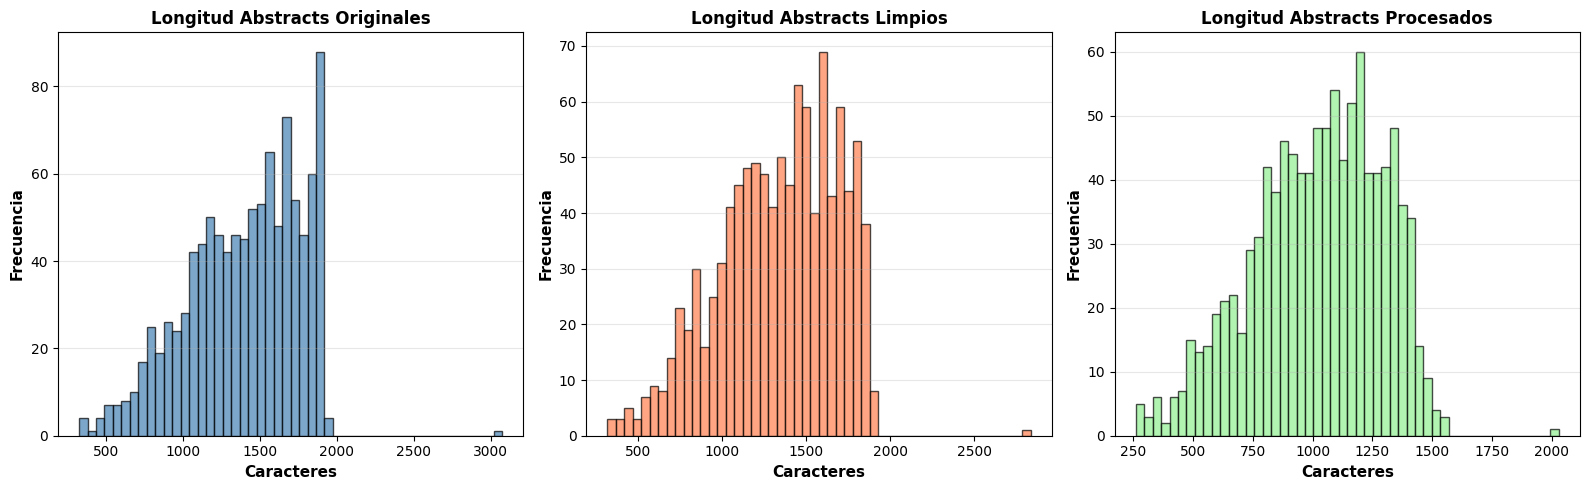


✓ Gráficos de longitud guardados en 'eda_abstract_length.png'


In [27]:
print("\n" + "="*70)
print("ANÁLISIS DE ABSTRACTS")
print("="*70)

# Longitud de abstracts antes y después de limpieza
df['abstract_length_raw'] = df['abstract'].str.len()
df['abstract_length_clean'] = df['abstract_limpio'].str.len()
df['abstract_length_processed'] = df['abstract_procesado'].str.len()

print("\nEstadísticas de longitud de abstracts:")
print("\nAbstracts originales:")
print(df['abstract_length_raw'].describe())
print("\nAbstracts limpios:")
print(df['abstract_length_clean'].describe())
print("\nAbstracts procesados:")
print(df['abstract_length_processed'].describe())

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogramas
axes[0].hist(df['abstract_length_raw'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Caracteres', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0].set_title('Longitud Abstracts Originales', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].hist(df['abstract_length_clean'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Caracteres', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[1].set_title('Longitud Abstracts Limpios', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

axes[2].hist(df['abstract_length_processed'], bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[2].set_xlabel('Caracteres', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[2].set_title('Longitud Abstracts Procesados', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_abstract_length.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Gráficos de longitud guardados en 'eda_abstract_length.png'")


ANÁLISIS DE FRECUENCIA DE PALABRAS

Total de palabras únicas: 11035
Total de palabras (con repeticiones): 128782
Palabra más frecuente aparece 2220 veces

Top 30 palabras más frecuentes:
----------------------------------------------------------------------
 1. radio                : 2220 veces (1.72%)
 2. data                 : 1485 veces (1.15%)
 3. observation          :  963 veces (0.75%)
 4. source               :  930 veces (0.72%)
 5. telescope            :  843 veces (0.65%)
 6. emission             :  842 veces (0.65%)
 7. array                :  756 veces (0.59%)
 8. frequency            :  661 veces (0.51%)
 9. image                :  651 veces (0.51%)
10. using                :  650 veces (0.50%)
11. model                :  511 veces (0.40%)
12. time                 :  487 veces (0.38%)
13. present              :  471 veces (0.37%)
14. vlbi                 :  465 veces (0.36%)
15. ghz                  :  461 veces (0.36%)
16. galaxy               :  451 veces (0.35%)
17. i

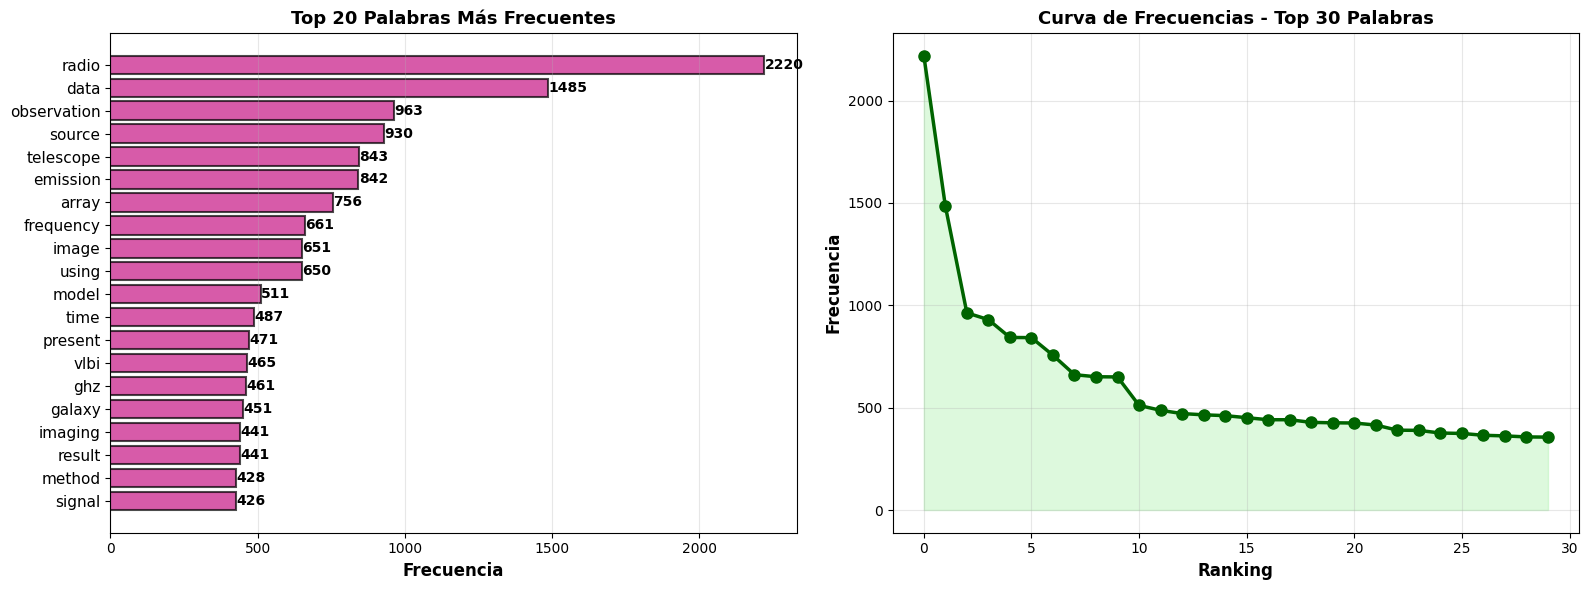


✓ Gráficos de frecuencia guardados en 'eda_word_frequency.png'


In [28]:
print("\n" + "="*70)
print("ANÁLISIS DE FRECUENCIA DE PALABRAS")
print("="*70)

# Contar frecuencias de palabras
from collections import Counter

# Todas las palabras procesadas
all_words = ' '.join(df['abstract_procesado'].tolist()).split()
word_freq = Counter(all_words)

print(f"\nTotal de palabras únicas: {len(word_freq)}")
print(f"Total de palabras (con repeticiones): {len(all_words)}")
print(f"Palabra más frecuente aparece {word_freq.most_common(1)[0][1]} veces")

# Top 30 palabras
top_words = word_freq.most_common(30)
print("\nTop 30 palabras más frecuentes:")
print("-" * 70)
for i, (word, freq) in enumerate(top_words, 1):
    print(f"{i:2d}. {word:20s} : {freq:4d} veces ({freq/len(all_words)*100:.2f}%)")

# Visualizar Top 20
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_20_words = word_freq.most_common(20)
words_20 = [w[0] for w in top_20_words]
freqs_20 = [w[1] for w in top_20_words]

# Gráfico de barras horizontal
axes[0].barh(range(len(words_20)), freqs_20, color='mediumvioletred', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_yticks(range(len(words_20)))
axes[0].set_yticklabels(words_20, fontsize=11)
axes[0].set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
axes[0].set_title('Top 20 Palabras Más Frecuentes', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Agregar valores
for i, v in enumerate(freqs_20):
    axes[0].text(v + 1, i, str(v), va='center', fontweight='bold', fontsize=10)

# Gráfico de línea - Top 30
top_30_words = word_freq.most_common(30)
words_30 = [w[0] for w in top_30_words]
freqs_30 = [w[1] for w in top_30_words]

axes[1].plot(range(len(words_30)), freqs_30, 'o-', linewidth=2.5, markersize=8, color='darkgreen')
axes[1].fill_between(range(len(words_30)), freqs_30, alpha=0.3, color='lightgreen')
axes[1].set_xlabel('Ranking', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
axes[1].set_title('Curva de Frecuencias - Top 30 Palabras', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_word_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Gráficos de frecuencia guardados en 'eda_word_frequency.png'")


GENERANDO NUBE DE PALABRAS


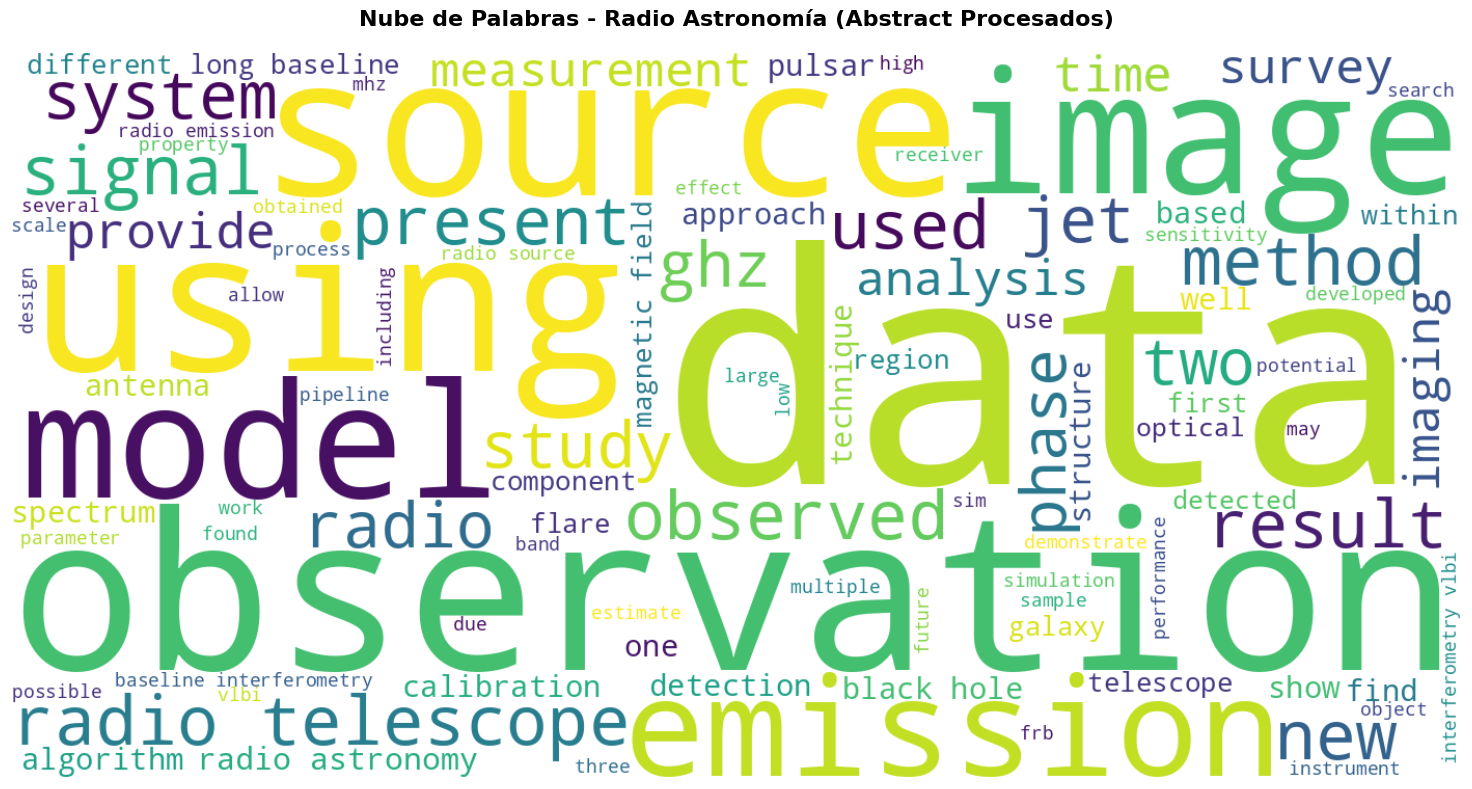


✓ Nube de palabras general guardada en 'wordcloud_general.png'


In [29]:
# Instalar wordcloud si no está disponible
# !pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("GENERANDO NUBE DE PALABRAS")
print("="*70)

# Crear texto completo
texto_completo = ' '.join(df['abstract_procesado'].tolist())

# Crear nube de palabras
wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    colormap='viridis',
    max_words=100,
    relative_scaling=0.5,
    min_font_size=10,
    contour_width=2,
    contour_color='steelblue'
).generate(texto_completo)

# Visualizar
fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nube de Palabras - Radio Astronomía (Abstract Procesados)', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('wordcloud_general.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Nube de palabras general guardada en 'wordcloud_general.png'")


NUBES DE PALABRAS POR CATEGORÍA


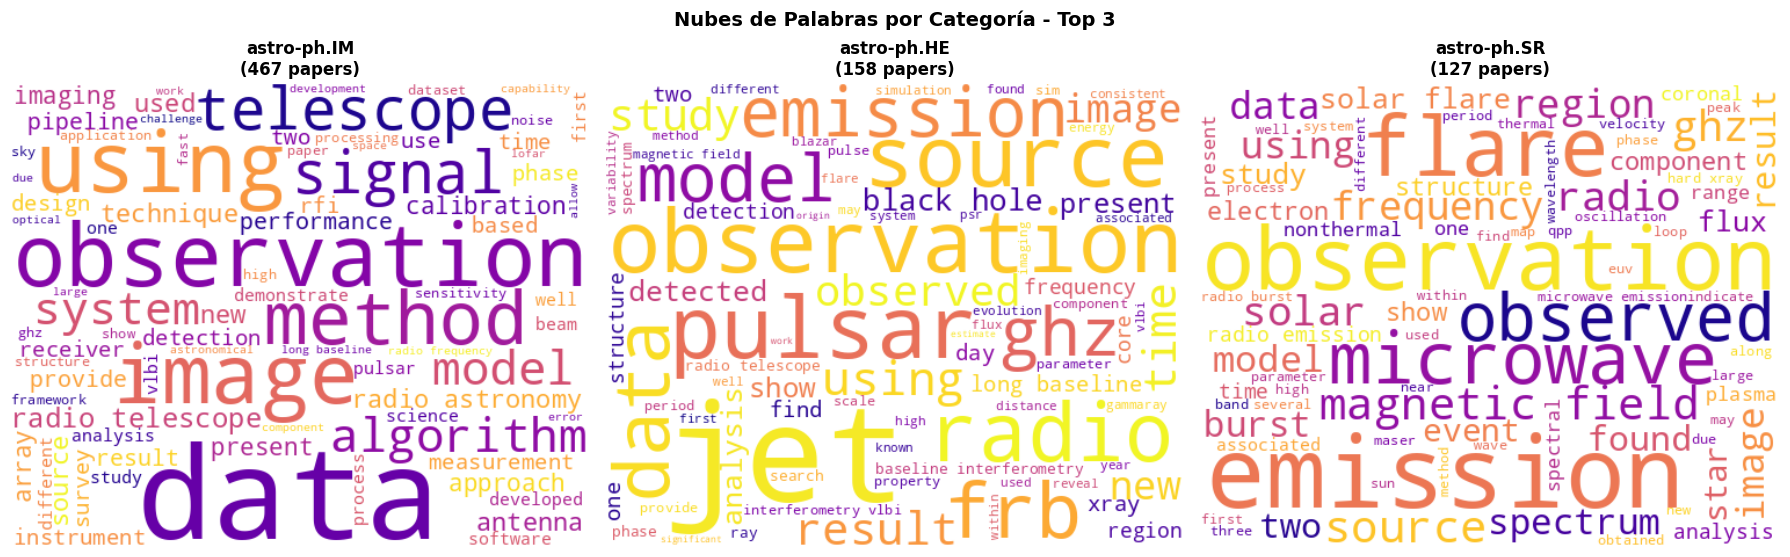


✓ Nubes por categoría guardadas en 'wordcloud_by_category.png'


In [30]:
print("\n" + "="*70)
print("NUBES DE PALABRAS POR CATEGORÍA")
print("="*70)

# Top 3 categorías
top_3_cats = df['category'].value_counts().head(3).index

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, category in enumerate(top_3_cats):
    # Textos de esa categoría
    cat_data = df[df['category'] == category]
    cat_text = ' '.join(cat_data['abstract_procesado'].tolist())
    
    # Crear nube
    wc = WordCloud(
        width=500,
        height=400,
        background_color='white',
        colormap='plasma',
        max_words=80,
        relative_scaling=0.5,
        min_font_size=8
    ).generate(cat_text)
    
    # Mostrar
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f'{category}\n({len(cat_data)} papers)', 
                        fontsize=12, fontweight='bold')

plt.suptitle('Nubes de Palabras por Categoría - Top 3', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('wordcloud_by_category.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Nubes por categoría guardadas en 'wordcloud_by_category.png'")


LEY DE ZIPF - ANÁLISIS DE DISTRIBUCIÓN DE PALABRAS


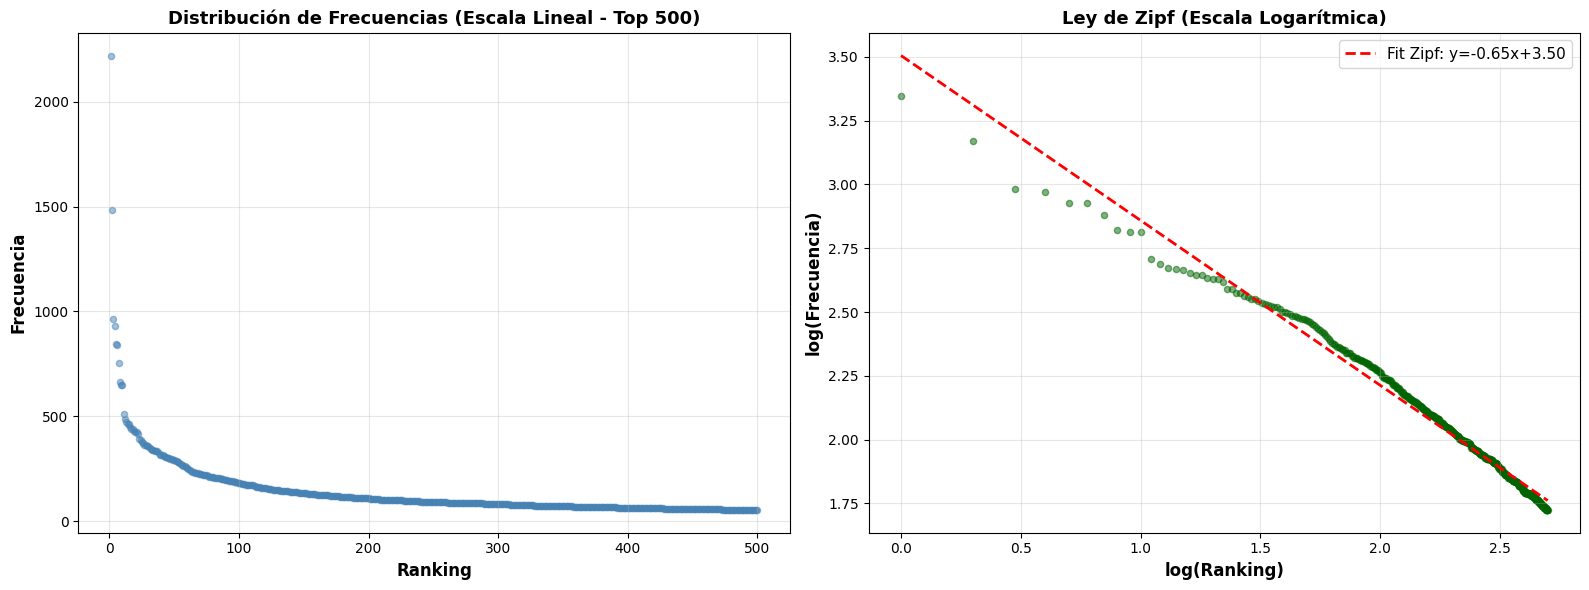


Coeficiente Zipf: -0.65
Intercepto: 3.50

Interpretación: La distribución sigue aproximadamente la Ley de Zipf
(Las palabras más frecuentes son mucho más comunes que las menos frecuentes)

✓ Gráficos Ley de Zipf guardados en 'eda_zipf_law.png'


In [31]:
print("\n" + "="*70)
print("LEY DE ZIPF - ANÁLISIS DE DISTRIBUCIÓN DE PALABRAS")
print("="*70)

# Ordenar por frecuencia
sorted_freq = sorted(word_freq.values(), reverse=True)
ranks = range(1, len(sorted_freq) + 1)

# Calcular log para Zipf
import numpy as np
log_ranks = np.log10(ranks)
log_freqs = np.log10(sorted_freq)

# Visualizar Ley de Zipf
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Escala lineal
axes[0].scatter(ranks[:500], sorted_freq[:500], alpha=0.5, s=20, color='steelblue')
axes[0].set_xlabel('Ranking', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Frecuencias (Escala Lineal - Top 500)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Escala logarítmica (Ley de Zipf)
axes[1].scatter(log_ranks[:500], log_freqs[:500], alpha=0.5, s=20, color='darkgreen')

# Fit línea Zipf
z = np.polyfit(log_ranks[:500], log_freqs[:500], 1)
p = np.poly1d(z)
axes[1].plot(log_ranks[:500], p(log_ranks[:500]), 'r--', linewidth=2, label=f'Fit Zipf: y={z[0]:.2f}x+{z[1]:.2f}')

axes[1].set_xlabel('log(Ranking)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('log(Frecuencia)', fontsize=12, fontweight='bold')
axes[1].set_title('Ley de Zipf (Escala Logarítmica)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_zipf_law.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCoeficiente Zipf: {z[0]:.2f}")
print(f"Intercepto: {z[1]:.2f}")
print("\nInterpretación: La distribución sigue aproximadamente la Ley de Zipf")
print(f"(Las palabras más frecuentes son mucho más comunes que las menos frecuentes)")

print("\n✓ Gráficos Ley de Zipf guardados en 'eda_zipf_law.png'")


COMPARACIÓN: PALABRAS ANTES Y DESPUÉS DE LIMPIEZA


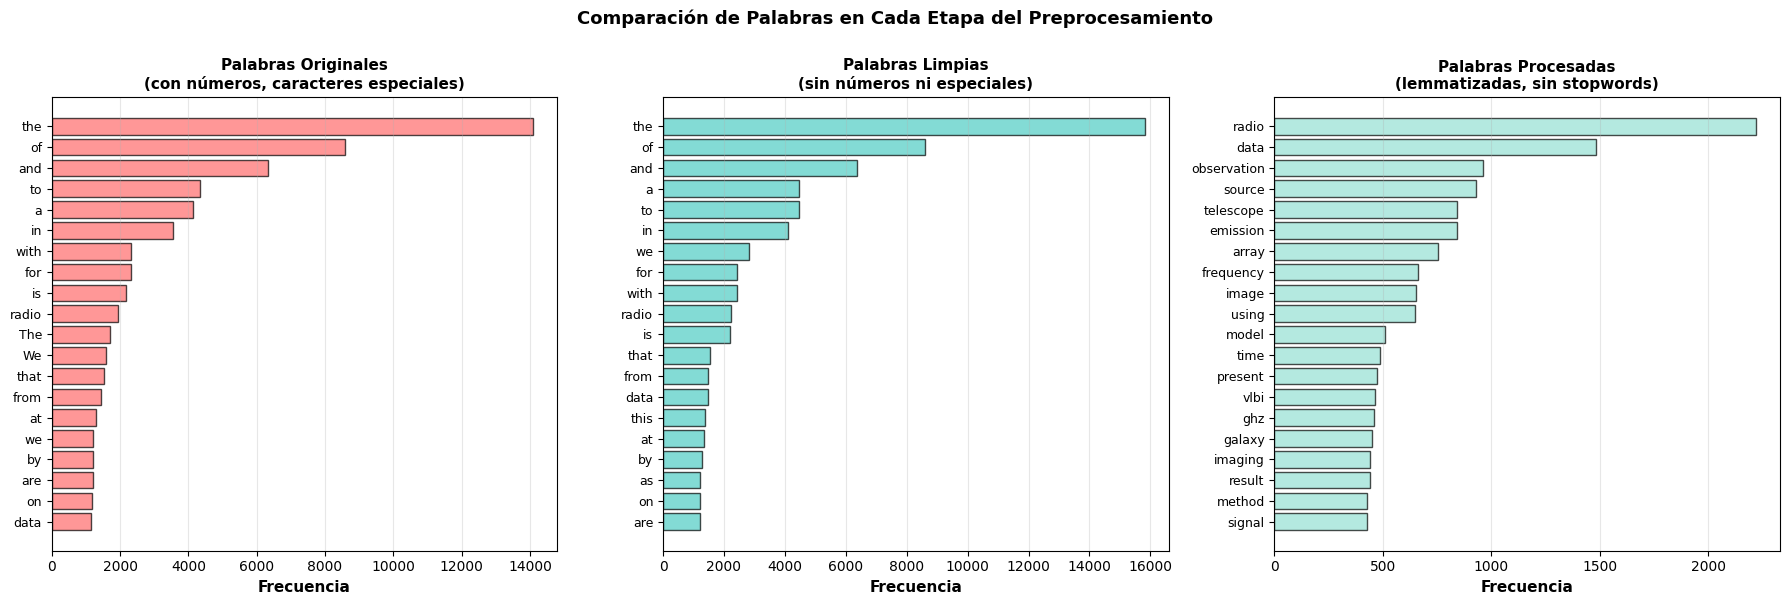


✓ Comparación guardada en 'eda_processing_comparison.png'


In [32]:
print("\n" + "="*70)
print("COMPARACIÓN: PALABRAS ANTES Y DESPUÉS DE LIMPIEZA")
print("="*70)

# Palabras limpias (sin procesamiento)
from collections import Counter
clean_words = ' '.join(df['abstract_limpio'].tolist()).split()
clean_word_freq = Counter(clean_words)

# Top palabras en cada etapa
top_raw = Counter(' '.join(df['abstract'].tolist()).split()).most_common(20)
top_clean = clean_word_freq.most_common(20)
top_processed = word_freq.most_common(20)

# Visualizar comparación
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Abstracts originales
raw_words = [w[0][:15] for w in top_raw]
raw_freqs = [w[1] for w in top_raw]
axes[0].barh(range(len(raw_words)), raw_freqs, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(raw_words)))
axes[0].set_yticklabels(raw_words, fontsize=9)
axes[0].set_xlabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0].set_title('Palabras Originales\n(con números, caracteres especiales)', fontsize=11, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Abstracts limpios
clean_words_list = [w[0][:15] for w in top_clean]
clean_freqs = [w[1] for w in top_clean]
axes[1].barh(range(len(clean_words_list)), clean_freqs, color='#4ECDC4', alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(clean_words_list)))
axes[1].set_yticklabels(clean_words_list, fontsize=9)
axes[1].set_xlabel('Frecuencia', fontsize=11, fontweight='bold')
axes[1].set_title('Palabras Limpias\n(sin números ni especiales)', fontsize=11, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

# Abstracts procesados
proc_words = [w[0][:15] for w in top_processed]
proc_freqs = [w[1] for w in top_processed]
axes[2].barh(range(len(proc_words)), proc_freqs, color='#95E1D3', alpha=0.7, edgecolor='black')
axes[2].set_yticks(range(len(proc_words)))
axes[2].set_yticklabels(proc_words, fontsize=9)
axes[2].set_xlabel('Frecuencia', fontsize=11, fontweight='bold')
axes[2].set_title('Palabras Procesadas\n(lemmatizadas, sin stopwords)', fontsize=11, fontweight='bold')
axes[2].invert_yaxis()
axes[2].grid(True, alpha=0.3, axis='x')

plt.suptitle('Comparación de Palabras en Cada Etapa del Preprocesamiento', 
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('eda_processing_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Comparación guardada en 'eda_processing_comparison.png'")

In [33]:
print("\n" + "="*70)
print("RESUMEN EJECUTIVO - ANÁLISIS EXPLORATORIO")
print("="*70)

summary_eda = {
    'Total de Papers': len(df),
    'Palabras Únicas': len(word_freq),
    'Palabras Totales': len(all_words),
    'Categorías': df['category'].nunique(),
    'Rango Temporal': f"{df['date'].dt.year.min()} - {df['date'].dt.year.max()}",
    'Promedio Chars (Original)': f"{df['abstract_length_raw'].mean():.0f}",
    'Promedio Chars (Procesado)': f"{df['abstract_length_processed'].mean():.0f}",
    'Palabra Más Frecuente': f"{word_freq.most_common(1)[0][0]} ({word_freq.most_common(1)[0][1]} veces)",
    'Entropia Shannon': -sum([p/len(all_words) * np.log2(p/len(all_words)) 
                               for p in word_freq.values() if p > 0]) / np.log2(len(word_freq))
}

print("\n" + "-" * 70)
for key, value in summary_eda.items():
    print(f"{key:.<45} {value}")
print("-" * 70)

print("\n📊 ARCHIVOS GENERADOS EN EDA:")
print("  ✓ eda_temporal_distribution.png")
print("  ✓ eda_categories.png")
print("  ✓ eda_abstract_length.png")
print("  ✓ eda_word_frequency.png")
print("  ✓ wordcloud_general.png")
print("  ✓ wordcloud_by_category.png")
print("  ✓ eda_zipf_law.png")
print("  ✓ eda_processing_comparison.png")

print("\n✓ Análisis Exploratorio completado exitosamente!")


RESUMEN EJECUTIVO - ANÁLISIS EXPLORATORIO

----------------------------------------------------------------------
Total de Papers.............................. 1039
Palabras Únicas.............................. 11035
Palabras Totales............................. 128782
Categorías................................... 29
Rango Temporal............................... 1994 - 2025
Promedio Chars (Original).................... 1400
Promedio Chars (Procesado)................... 1020
Palabra Más Frecuente........................ radio (2220 veces)
Entropia Shannon............................. 0.8288591811553878
----------------------------------------------------------------------

📊 ARCHIVOS GENERADOS EN EDA:
  ✓ eda_temporal_distribution.png
  ✓ eda_categories.png
  ✓ eda_abstract_length.png
  ✓ eda_word_frequency.png
  ✓ wordcloud_general.png
  ✓ wordcloud_by_category.png
  ✓ eda_zipf_law.png
  ✓ eda_processing_comparison.png

✓ Análisis Exploratorio completado exitosamente!


## Limpieza

In [76]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk

# Descargar recursos necesarios
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

def limpiar_texto(texto):
    """
    Función completa de limpieza de texto
    """
    if pd.isna(texto):
        return ""
    
    # Convertir a minúsculas
    texto = texto.lower()
    
    # Remover URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
    
    # Remover emails
    texto = re.sub(r'\S+@\S+', '', texto)
    
    # Remover caracteres especiales y números
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    
    # Remover espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    return texto

# Aplicar limpieza
print("Limpiando textos...")
df['abstract_limpio'] = df['abstract'].apply(limpiar_texto)

print(f"\nAbstract original:\n{df['abstract'].iloc[0][:200]}...")
print(f"\nAbstract limpio:\n{df['abstract_limpio'].iloc[0][:200]}...")
print(f"\nTextos vacíos tras limpieza: {(df['abstract_limpio'] == '').sum()}")

# Remover textos vacíos
df = df[df['abstract_limpio'].str.len() > 50].reset_index(drop=True)
print(f"\nDataset después de limpieza: {len(df)} papers")

Limpiando textos...

Abstract original:
Extracting polarimetric information from very long baseline interferometry (VLBI) data is demanding but vital for understanding the synchrotron radiation process and the magnetic fields of celestial o...

Abstract limpio:
extracting polarimetric information from very long baseline interferometry vlbi data is demanding but vital for understanding the synchrotron radiation process and the magnetic fields of celestial obj...

Textos vacíos tras limpieza: 0

Dataset después de limpieza: 1039 papers


## Procesamiento

In [82]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocesar_texto(texto):
    """
    Tokenización, eliminación de stopwords y lemmatización
    """
    # Tokenizar
    tokens = word_tokenize(texto)
    
    # Eliminar stopwords y palabras muy cortas
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    
    # Lemmatizar
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return ' '.join(tokens)

print("Preprocesando textos (esto puede tomar un minuto)...")
df['abstract_procesado'] = df['abstract_limpio'].apply(preprocesar_texto)

print(f"\nAbstract procesado:\n{df['abstract_procesado'].iloc[0][:200]}...")

# Guardar dataset procesado
df.to_csv('arxiv_radio_astronomy_processed.csv', index=False)
print("\nDataset procesado guardado en 'arxiv_radio_astronomy_processed.csv'")

Preprocesando textos (esto puede tomar un minuto)...

Abstract procesado:
extracting polarimetric information long baseline interferometry vlbi data demanding vital understanding synchrotron radiation process magnetic field celestial object active galactic nucleus agns howe...

Dataset procesado guardado en 'arxiv_radio_astronomy_processed.csv'


## Matriz TF-IDF

In [59]:
print("="*60)
print("VECTORIZACIÓN - TF-IDF")
print("="*60)

# Crear vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,           # Limitar a 100 features
    min_df=2,                   # Mínimo 2 documentos
    max_df=0.8,                 # Máximo 80% de documentos
    ngram_range=(1, 2),         # Unigramas y bigramas
    strip_accents='unicode',
    lowercase=True,
    analyzer='word',
    token_pattern=r'(?u)\b\w+\b'
)

# Crear matriz TF-IDF
tfidf_matrix = tfidf_vectorizer.fit_transform(df['abstract_procesado'])

print(f"\nForma de matriz TF-IDF: {tfidf_matrix.shape}")
print(f"Memoria usada: {tfidf_matrix.data.nbytes / 1024 / 1024:.2f} MB")
print(f"Sparsidad: {1.0 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.2%}")

# Obtener feature names
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nPrimeras 10 features:\n{feature_names[:10]}")

# Imprimir algunas filas de la matriz TF-IDF    
print(f"\nPrimeras filas de la matriz TF-IDF:\n{tfidf_matrix[:5].toarray()}")

# Guardar matriz
np.save('tfidf_matrix.npy', tfidf_matrix.toarray())
print("\nMatriz TF-IDF guardada")

VECTORIZACIÓN - TF-IDF

Forma de matriz TF-IDF: (1039, 100)
Memoria usada: 0.16 MB
Sparsidad: 79.91%

Primeras 10 features:
['algorithm' 'also' 'analysis' 'antenna' 'approach' 'array' 'astronomy'
 'band' 'based' 'baseline']

Primeras filas de la matriz TF-IDF:
[[0.         0.         0.         0.         0.17046202 0.05539572
  0.         0.         0.         0.07387694 0.         0.
  0.         0.         0.59173551 0.         0.19287517 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.07817735 0.         0.         0.
  0.08978731 0.         0.         0.15497104 0.         0.
  0.08237138 0.34788025 0.37878454 0.07120211 0.         0.
  0.         0.07817735 0.08318498 0.         0.09490249 0.
  0.38139216 0.         0.         0.         0.         0.0508448
  0.         0.         0.         0.         0.         0.
  0.         0.09125535 0.05988932 0.08523101 0.         0.
  0.         0.         0.         0.         0.         0.
  0.

## VECTORIZACIÓN - BAG OF WORDS

In [60]:
print("="*60)
print("VECTORIZACIÓN - BAG OF WORDS")
print("="*60)

# Crear vectorizador BoW
bow_vectorizer = CountVectorizer(
    max_features=100,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2)
)

# Crear matriz BoW
bow_matrix = bow_vectorizer.fit_transform(df['abstract_procesado'])

print(f"\nForma de matriz BoW: {bow_matrix.shape}")
print(f"Densidad: {bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1]):.2%}")

# Mostrar palabras más frecuentes
feature_names_bow = bow_vectorizer.get_feature_names_out()
word_freq = np.array(bow_matrix.sum(axis=0)).flatten()
top_words_idx = word_freq.argsort()[-15:][::-1]

print(f"\nPalabras más frecuentes:")
for idx in top_words_idx:
    print(f"  {feature_names_bow[idx]}: {word_freq[idx]:.0f}")

VECTORIZACIÓN - BAG OF WORDS



Forma de matriz BoW: (1039, 100)
Densidad: 20.09%

Palabras más frecuentes:
  data: 1485
  observation: 963
  source: 930
  telescope: 843
  emission: 842
  array: 756
  frequency: 661
  image: 651
  using: 650
  model: 511
  time: 487
  present: 471
  vlbi: 465
  ghz: 461
  galaxy: 451


## K-MEANS

ENCONTRAR NÚMERO ÓPTIMO DE CLUSTERS

Calculando métricas para K=2 a K=10...
K=2: Inertia=842.21, Silhouette=0.0460
K=3: Inertia=812.40, Silhouette=0.0529
K=4: Inertia=787.98, Silhouette=0.0564
K=5: Inertia=764.47, Silhouette=0.0659
K=6: Inertia=745.10, Silhouette=0.0697
K=7: Inertia=726.01, Silhouette=0.0737
K=8: Inertia=704.76, Silhouette=0.0842
K=9: Inertia=687.00, Silhouette=0.0899
K=10: Inertia=671.55, Silhouette=0.0965


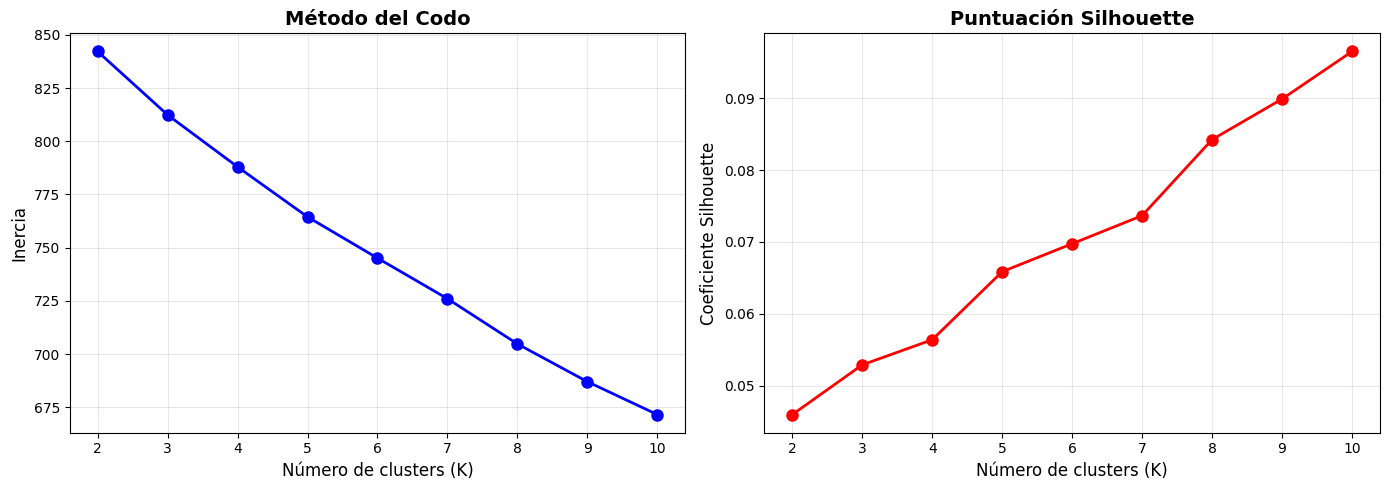


✓ K óptimo según Silhouette: 10


In [61]:
print("="*60)
print("ENCONTRAR NÚMERO ÓPTIMO DE CLUSTERS")
print("="*60)

inertias = []
silhouette_scores = []
K_range = range(2, 11)

print("\nCalculando métricas para K=2 a K=10...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(tfidf_matrix)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(tfidf_matrix, kmeans.labels_))
    
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

# Graficar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de clusters (K)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del Codo', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de clusters (K)', fontsize=12)
axes[1].set_ylabel('Coeficiente Silhouette', fontsize=12)
axes[1].set_title('Puntuación Silhouette', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimal_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

# Encontrar K óptimo
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✓ K óptimo según Silhouette: {optimal_k}")

In [62]:
print("="*60)
print("CLUSTERING - K-MEANS")
print("="*60)

# Usar K óptimo 
optimal_k = 10

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=15, max_iter=300)
df['cluster_kmeans'] = kmeans.fit_predict(tfidf_matrix)

print(f"\nClusters K-Means (K={optimal_k}):")
print(df['cluster_kmeans'].value_counts().sort_index())

# Calcular métricas
sil_score = silhouette_score(tfidf_matrix, df['cluster_kmeans'])
db_score = davies_bouldin_score(tfidf_matrix.toarray(), df['cluster_kmeans'])

print(f"\nMétricas:")
print(f"  Silhouette Score: {sil_score:.4f}")
print(f"  Davies-Bouldin Index: {db_score:.4f}")

# Palabras representativas por cluster
print(f"\nPalabras representativas por cluster:")
centroids = kmeans.cluster_centers_
feature_names = tfidf_vectorizer.get_feature_names_out()

for cluster_id in range(optimal_k):
    top_indices = centroids[cluster_id].argsort()[-8:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f"\n  Cluster {cluster_id}: {', '.join(top_words)}")

CLUSTERING - K-MEANS



Clusters K-Means (K=10):
cluster_kmeans
0    107
1    171
2    199
3    147
4     50
5     59
6     98
7     58
8    101
9     49
Name: count, dtype: int64

Métricas:
  Silhouette Score: 0.0965
  Davies-Bouldin Index: 2.8496

Palabras representativas por cluster:

  Cluster 0: flare, solar, emission, magnetic, microwave, electron, burst, field

  Cluster 1: antenna, array, system, signal, telescope, beam, receiver, frequency

  Cluster 2: galaxy, emission, source, line, observation, star, survey, spectrum

  Cluster 3: data, pipeline, processing, astronomy, survey, radio astronomy, algorithm, using

  Cluster 4: jet, vlbi, ghz, observation, magnetic, long baseline, long, source

  Cluster 5: pulsar, data, telescope, observation, fast, time, frequency, radio telescope

  Cluster 6: vlbi, baseline, interferometry, source, long baseline, long, observation, ghz

  Cluster 7: hole, black, black hole, baseline, vlbi, image, interferometry, long baseline

  Cluster 8: image, reconstruction, 

## Visualización 2D

VISUALIZACIÓN 2D DE CLUSTERS
Aplicando PCA para reducción a 2D...
Varianza explicada:
  • Componente 1: 5.94%
  • Componente 2: 4.71%
  • Total: 10.65%

Añadiendo títulos representativos...


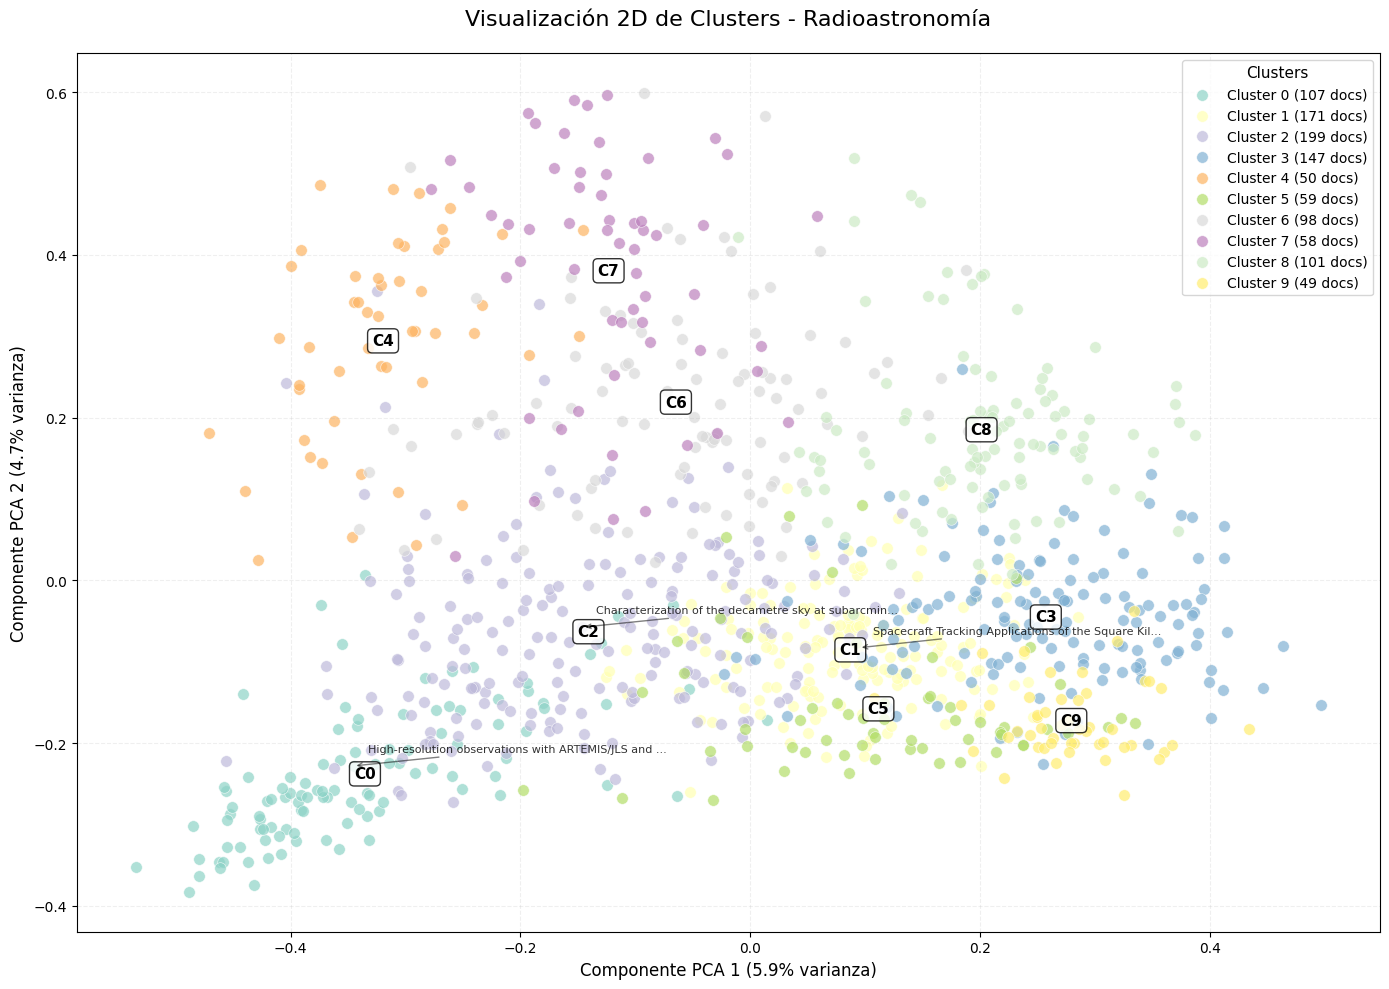

In [ ]:
print("=" * 60)
print("VISUALIZACIÓN 2D DE CLUSTERS")
print("=" * 60)

# Reducción de dimensionalidad con PCA
print("Aplicando PCA para reducción a 2D...")
pca = PCA(n_components=2, random_state=42)
tfidf_2d = pca.fit_transform(tfidf_matrix.toarray())

# Añadir coordenadas PCA al DataFrame
df['pca_x'] = tfidf_2d[:, 0]
df['pca_y'] = tfidf_2d[:, 1]

# Varianza explicada
var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada:")
print(f"  • Componente 1: {var_exp[0]:.2%}")
print(f"  • Componente 2: {var_exp[1]:.2%}")
print(f"  • Total: {sum(var_exp):.2%}")

# Crear visualización
plt.figure(figsize=(14, 10))

# Scatter plot por cluster
clusters = sorted(df['cluster_kmeans'].unique())
colors = plt.cm.Set3(np.linspace(0, 1, len(clusters)))

for cluster, color in zip(clusters, colors):
    cluster_data = df[df['cluster_kmeans'] == cluster]
    
    plt.scatter(
        cluster_data['pca_x'], 
        cluster_data['pca_y'],
        c=[color],
        s=70,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5,
        label=f'Cluster {cluster} ({len(cluster_data)} docs)'
    )
    
    # Añadir etiqueta del cluster en el centroide
    centroide_x = cluster_data['pca_x'].mean()
    centroide_y = cluster_data['pca_y'].mean()
    plt.annotate(
        f'C{cluster}',
        xy=(centroide_x, centroide_y),
        xytext=(0, 0),
        textcoords='offset points',
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
    )

plt.xlabel(f'Componente PCA 1 ({var_exp[0]:.1%} varianza)', fontsize=12)
plt.ylabel(f'Componente PCA 2 ({var_exp[1]:.1%} varianza)', fontsize=12)
plt.title('Visualización 2D de Clusters - Radioastronomía', fontsize=16, pad=20)
plt.legend(title='Clusters', fontsize=10, title_fontsize=11)
plt.grid(True, alpha=0.2, linestyle='--')
plt.tight_layout()

# Añadir algunos títulos representativos
print("\nAñadiendo títulos representativos...")
for cluster in clusters[:3]:  # Solo primeros 3 clusters para no saturar
    cluster_data = df[df['cluster_kmeans'] == cluster]
    if len(cluster_data) > 0:
        # Tomar el documento más cercano al centroide en 2D
        centroide_2d = cluster_data[['pca_x', 'pca_y']].mean()
        distancias = np.sqrt(
            (cluster_data['pca_x'] - centroide_2d[0])**2 + 
            (cluster_data['pca_y'] - centroide_2d[1])**2
        )
        idx_representativo = distancias.idxmin()
        
        titulo_corto = df.loc[idx_representativo, 'title'][:50] + "..."
        plt.annotate(
            titulo_corto,
            xy=(df.loc[idx_representativo, 'pca_x'], df.loc[idx_representativo, 'pca_y']),
            xytext=(10, 10),
            textcoords='offset points',
            fontsize=8,
            alpha=0.8,
            arrowprops=dict(arrowstyle='->', alpha=0.5)
        )

plt.show()

## ANÁLISIS DE TÓPICOS

In [17]:
print("="*60)
print("ANÁLISIS DE TÓPICOS - LDA")
print("="*60)

# Usar Bag of Words para LDA
lda = LatentDirichletAllocation(
    n_components=optimal_k,
    random_state=42,
    max_iter=50,
    learning_method='online',
    verbose=0
)

lda.fit(bow_matrix)

# Obtener tópicos
print(f"\nTópicos extraídos (K={optimal_k}):\n")
feature_names = bow_vectorizer.get_feature_names_out()

for topic_id, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    print(f"Tópico {topic_id}: {', '.join(top_words)}")

# Asignar documentos a tópicos dominantes
doc_topic_dist = lda.transform(bow_matrix)
df['topic_lda'] = doc_topic_dist.argmax(axis=1)

print(f"\nDistribución de documentos por tópico:")
print(df['topic_lda'].value_counts().sort_index())

ANÁLISIS DE TÓPICOS - LDA

Tópicos extraídos (K=5):

Tópico 0: vlbi, jet, baseline, long, hole, black, black hole, long baseline, interferometry, observation
Tópico 1: emission, source, observation, solar, flare, magnetic, spectral, region, field, line
Tópico 2: data, image, method, algorithm, imaging, technique, approach, model, astronomy, source
Tópico 3: frequency, telescope, receiver, system, pulsar, rfi, radio telescope, observation, data, signal
Tópico 4: array, galaxy, telescope, survey, antenna, phase, source, using, beam, observation

Distribución de documentos por tópico:
topic_lda
0    163
1    220
2    265
3    199
4    192
Name: count, dtype: int64


## INTERPRETACIÓN DE CLUSTERS 

In [36]:
print("="*60)
print("INTERPRETACIÓN DE CLUSTERS (K-MEANS)")
print("="*60)

for cluster_id in range(optimal_k):
    cluster_docs = df[df['cluster_kmeans'] == cluster_id]
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id} - {len(cluster_docs)} documentos ({len(cluster_docs)/len(df)*100:.1f}%)")
    print(f"{'='*60}")
    
    # Palabras más comunes
    cluster_text = ' '.join(cluster_docs['abstract_procesado'].tolist())
    tokens = cluster_text.split()
    from collections import Counter
    word_freq = Counter(tokens)
    
    print(f"\nPalabras más frecuentes:")
    for word, freq in word_freq.most_common(12):
        print(f"  • {word}: {freq}")
    
    # Categorías representativas
    print(f"\nCategorías de arXiv más frecuentes:")
    top_categories = cluster_docs['category'].value_counts().head(5)
    for cat, count in top_categories.items():
        print(f"  • {cat}: {count}")
    
    # Títulos de ejemplo
    print(f"\nEjemplos de papers en este cluster:")
    for idx, (_, row) in enumerate(cluster_docs.head(3).iterrows()):
        print(f"  {idx+1}. {row['title'][:70]}...")
    
    # Promedio de fechas
    avg_year = cluster_docs['date'].dt.year.mean()
    print(f"\nAño promedio: {avg_year:.0f}")
    # Asegurarse de que 'date' sea datetime (maneja strings / valores inválidos)
    date_series = pd.to_datetime(cluster_docs['date'], errors='coerce')
    if date_series.dropna().empty:
        print("\nAño promedio: N/A")
    else:
        avg_year = date_series.dt.year.mean()
        print(f"\nAño promedio: {avg_year:.0f}")

INTERPRETACIÓN DE CLUSTERS (K-MEANS)

CLUSTER 0 - 107 documentos (10.3%)

Palabras más frecuentes:
  • emission: 284
  • flare: 258
  • radio: 228
  • solar: 218
  • magnetic: 193
  • microwave: 161
  • electron: 151
  • field: 139
  • observation: 113
  • source: 107
  • observed: 106
  • burst: 104

Categorías de arXiv más frecuentes:
  • astro-ph.SR: 86
  • astro-ph: 9
  • astro-ph.HE: 7
  • astro-ph.IM: 3
  • astro-ph.CO: 1

Ejemplos de papers en este cluster:
  1. Constraining $γ$-ray dissipation site in gravitationally lensed quasar...
  2. The Variable Radio Emission of V830 Tau and Its Putative Planet...
  3. Multiwavelength Observations of the Precursors Before the Eruptive X4....

Año promedio: 2016

Año promedio: 2016

CLUSTER 1 - 171 documentos (16.5%)

Palabras más frecuentes:
  • radio: 314
  • array: 282
  • telescope: 212
  • antenna: 191
  • frequency: 173
  • system: 167
  • beam: 153
  • signal: 148
  • receiver: 124
  • observation: 121
  • calibration: 109
  • data

In [71]:
# ============================================
# CELDA 11: Análisis detallado por cluster
# ============================================

print("=" * 70)
print("ANÁLISIS DETALLADO POR CLUSTER")
print("=" * 70)

# Configurar pandas para mostrar más información
pd.set_option('display.max_colwidth', 100)

for cluster_num in sorted(df['cluster_kmeans'].unique()):
    cluster_data = df[df['cluster_kmeans'] == cluster_num]
    cluster_size = len(cluster_data)
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_num} - {cluster_size} documentos ({cluster_size/len(df)*100:.1f}%)")
    print(f"{'='*60}")
    
    # 1. Tema inferido del cluster
    print("\n1. TEMA PRINCIPAL INFERIDO:")
    
    # Analizar palabras clave
    cluster_text = ' '.join(cluster_data['abstract_procesado'])
    cluster_words = cluster_text.split()
    word_freq = Counter(cluster_words)
    
    # Palabras más distintivas
    top_words = [word for word, _ in word_freq.most_common(10)]
    
    # Inferir tema basado en palabras clave
    tema = "Radioastronomía General"
    
    if any(word in ['interferometry', 'vlbi', 'aperture'] for word in top_words[:5]):
        if any(word in ['image', 'reconstruction', 'cleanalgorithm'] for word in top_words):
            tema = "Interferometría y Reconstrucción de Imágenes"
        else:
            tema = "Técnicas Interferométricas"
    
    elif any(word in ['machine', 'learning', 'neural', 'deep'] for word in top_words[:5]):
        tema = "Aprendizaje Automático en Radioastronomía"
    
    elif any(word in ['signal', 'processing', 'rfi', 'mitigation'] for word in top_words[:5]):
        tema = "Procesamiento de Señales y RFI"
    
    elif any(word in ['calibration', 'calibrating', 'calibrated'] for word in top_words[:5]):
        tema = "Calibración de Datos Radioastronómicos"
    
    elif any(word in ['spectrum', 'spectral', 'line', 'molecular'] for word in top_words[:5]):
        tema = "Espectroscopia Radioastronómica"
    
    elif any(word in ['solar', 'sun', 'heliospheric'] for word in top_words[:5]):
        tema = "Radioastronomía Solar"
    
    print(f"   {tema}")
    
    # 2. Palabras clave distintivas
    print("\n2. PALABRAS CLAVE DISTINTIVAS:")
    for word, freq in word_freq.most_common(10):
        global_freq =word_freq.get(word, 0)
        ratio = freq / max(global_freq, 1)
        print(f"   {word:20} {freq:3d} (ratio: {ratio:.1f}x)")
    
    # 3. Categorías principales
    print("\n3. CATEGORÍAS DE ARXIV:")
    categorias = cluster_data['category'].value_counts()
    for cat, count in categorias.head(5).items():
        porcentaje = (count / cluster_size) * 100
        print(f"   {cat:15} {count:3d} documentos ({porcentaje:.1f}%)")
    
    # 4. Distribución temporal
    print("\n4. DISTRIBUCIÓN TEMPORAL:")
    if 'year' in cluster_data.columns:
        years = cluster_data['year'].value_counts().sort_index()
        if len(years) > 0:
            print(f"   Rango: {years.index.min()} - {years.index.max()}")
            print(f"   Promedio: {cluster_data['year'].mean():.1f}")
            print(f"   Documentos recientes (≥2020): {len(cluster_data[cluster_data['year'] >= 2020])}")
    
    # 5. Documentos representativos
    print("\n5. DOCUMENTOS REPRESENTATIVOS:")
    for i, (_, row) in enumerate(cluster_data.head(3).iterrows(), 1):
        print(f"   {i}. {row['title'][:70]}...")
        print(f"      {row['arxiv_id']} - {row['category']}")
    
    # 6. Oportunidades de investigación
    print("\n6. OPORTUNIDADES DE INVESTIGACIÓN IDENTIFICADAS:")
    
    # Verificar términos relacionados con ML
    terminos_ml = ['machine learning', 'deep learning', 'neural network', 'artificial intelligence']
    menciones_ml = sum(1 for term in terminos_ml if term in cluster_text)
    
    if menciones_ml > 0:
        print(f"   • Aplicación de técnicas avanzadas de ML ({menciones_ml} menciones)")
    else:
        print(f"   • Oportunidad para aplicar técnicas de ML (0 menciones)")
    
    # Verificar big data
    terminos_bigdata = ['big data', 'large scale', 'data intensive', 'pipeline']
    menciones_bigdata = sum(1 for term in terminos_bigdata if term in cluster_text)
    
    if menciones_bigdata > 0:
        print(f"   • Gestión de grandes volúmenes de datos ({menciones_bigdata} menciones)")
    else:
        print(f"   • Oportunidad en procesamiento de big data")
    
    # Verificar aplicaciones prácticas
    terminos_aplicaciones = ['application', 'implementation', 'real world', 'practical']
    menciones_aplicaciones = sum(1 for term in terminos_aplicaciones if term in cluster_text)
    
    if menciones_aplicaciones > 3:
        print(f"   • Enfoque aplicado ({menciones_aplicaciones} menciones)")
    else:
        print(f"   • Oportunidad para desarrollos aplicados")

print("\n" + "="*70)
print("ANÁLISIS COMPLETADO")
print("="*70)

ANÁLISIS DETALLADO POR CLUSTER

CLUSTER 0 - 107 documentos (10.3%)

1. TEMA PRINCIPAL INFERIDO:
   Radioastronomía Solar

2. PALABRAS CLAVE DISTINTIVAS:
   emission             284 (ratio: 1.0x)
   flare                258 (ratio: 1.0x)
   radio                228 (ratio: 1.0x)
   solar                218 (ratio: 1.0x)
   magnetic             193 (ratio: 1.0x)
   microwave            161 (ratio: 1.0x)
   electron             151 (ratio: 1.0x)
   field                139 (ratio: 1.0x)
   observation          113 (ratio: 1.0x)
   source               107 (ratio: 1.0x)

3. CATEGORÍAS DE ARXIV:
   astro-ph.SR      86 documentos (80.4%)
   astro-ph          9 documentos (8.4%)
   astro-ph.HE       7 documentos (6.5%)
   astro-ph.IM       3 documentos (2.8%)
   astro-ph.CO       1 documentos (0.9%)

4. DISTRIBUCIÓN TEMPORAL:

5. DOCUMENTOS REPRESENTATIVOS:
   1. Constraining $γ$-ray dissipation site in gravitationally lensed quasar...
      2501.04775v2 - astro-ph.HE
   2. The Variable Radio

In [73]:
# ============================================
# CELDA 12: Evaluación de clusters para tema de tesis
# ============================================

print("=" * 70)
print("EVALUACIÓN DE CLUSTERS PARA SELECCIÓN DE TEMA DE TESIS")
print("=" * 70)

# Criterios de evaluación para cada cluster
criterios = [
    "Tamaño del cluster (documentos)",
    "Crecimiento reciente (publicaciones ≥2020)",
    "Diversidad de subtemas",
    "Presencia de técnicas modernas (ML/AI)",
    "Aplicabilidad práctica",
    "Relevancia para proyectos actuales"
]

print("\nCRITERIOS DE EVALUACIÓN:")
for i, criterio in enumerate(criterios, 1):
    print(f"  {i}. {criterio}")

print("\n" + "-"*70)
print("EVALUACIÓN POR CLUSTER:")
print("-"*70)

# Calcular puntajes para cada cluster
puntajes_clusters = []

for cluster_num in sorted(df['cluster_kmeans'].unique()):
    cluster_data = df[df['cluster_kmeans'] == cluster_num]
    cluster_size = len(cluster_data)
    
    # 1. Tamaño del cluster (0-20 puntos)
    tamaño_score = min(20, cluster_size / 5)
    
    # 2. Crecimiento reciente (0-20 puntos)
    if 'year' in cluster_data.columns:
        recientes = len(cluster_data[cluster_data['year'] >= 2020])
        crecimiento_score = min(20, recientes / max(1, cluster_size / 5))
    else:
        crecimiento_score = 10
    
    # 3. Diversidad de subtemas (0-15 puntos)
    categorias_unicas = cluster_data['category'].nunique()
    diversidad_score = min(15, categorias_unicas * 3)
    
    # 4. Presencia de ML/AI (0-25 puntos)
    cluster_text = ' '.join(cluster_data['abstract_procesado']).lower()
    terminos_ml = ['machine learning', 'deep learning', 'neural network', 
                   'artificial intelligence', 'ml', 'ai', 'convolutional']
    menciones_ml = sum(1 for term in terminos_ml if term in cluster_text)
    ml_score = min(25, menciones_ml * 5)
    
    # 5. Aplicabilidad práctica (0-10 puntos)
    terminos_practicos = ['application', 'implement', 'practical', 'real world',
                         'deploy', 'production', 'software', 'tool']
    menciones_practicas = sum(1 for term in terminos_practicos if term in cluster_text)
    practico_score = min(10, menciones_practicas * 2)
    
    # 6. Relevancia para proyectos (0-10 puntos)
    terminos_proyectos = ['ska', 'alma', 'vla', 'meerkat', 'askap', 'chime',
                         'lofar', 'event horizon', 'gravitational wave']
    menciones_proyectos = sum(1 for term in terminos_proyectos if term in cluster_text)
    proyectos_score = min(10, menciones_proyectos * 2)
    
    # Puntaje total
    total_score = (tamaño_score + crecimiento_score + diversidad_score + 
                  ml_score + practico_score + proyectos_score)
    
    puntajes_clusters.append({
        'cluster': cluster_num,
        'tamaño': cluster_size,
        'puntaje_total': total_score,
        'tamaño_score': tamaño_score,
        'crecimiento_score': crecimiento_score,
        'diversidad_score': diversidad_score,
        'ml_score': ml_score,
        'practico_score': practico_score,
        'proyectos_score': proyectos_score
    })
    
    # Mostrar evaluación
    print(f"\nCLUSTER {cluster_num} ({cluster_size} documentos):")
    print(f"  Tamaño:                {tamaño_score:.1f}/20")
    print(f"  Crecimiento reciente:  {crecimiento_score:.1f}/20")
    print(f"  Diversidad:            {diversidad_score:.1f}/15")
    print(f"  ML/AI:                 {ml_score:.1f}/25")
    print(f"  Aplicabilidad:         {practico_score:.1f}/10")
    print(f"  Relevancia proyectos:  {proyectos_score:.1f}/10")
    print(f"  {'-'*40}")
    print(f"  TOTAL:                 {total_score:.1f}/100")

# Ordenar clusters por puntaje
puntajes_df = pd.DataFrame(puntajes_clusters)
puntajes_df = puntajes_df.sort_values('puntaje_total', ascending=False)

print("\n" + "="*70)
print("RANKING DE CLUSTERS POR POTENCIAL PARA TESIS")
print("="*70)

print("\nCluster | Puntaje | Tamaño | ML Score | Crecimiento | Aplicabilidad")
print("-"*70)

for _, row in puntajes_df.iterrows():
    print(f"{row['cluster']:7} | {row['puntaje_total']:7.1f} | {row['tamaño']:6} | "
          f"{row['ml_score']:8.1f} | {row['crecimiento_score']:11.1f} | "
          f"{row['practico_score']:13.1f}")

# Recomendación final
mejor_cluster = puntajes_df.iloc[0]
print("\n" + "="*70)
print("RECOMENDACIÓN FINAL")
print("="*70)
print(f"\n✓ CLUSTER RECOMENDADO: {mejor_cluster['cluster']}")
print(f"  • Puntaje total: {mejor_cluster['puntaje_total']:.1f}/100")
print(f"  • Tamaño: {mejor_cluster['tamaño']} documentos")
print(f"  • Fortalezas:")
print(f"    - Presencia de ML/AI: {mejor_cluster['ml_score']:.1f}/25")
print(f"    - Crecimiento reciente: {mejor_cluster['crecimiento_score']:.1f}/20")
print(f"    - Aplicabilidad: {mejor_cluster['practico_score']:.1f}/10")

# Guardar evaluación
puntajes_df.to_csv("evaluacion_clusters_tesis.csv", index=False)
print(f"\nEvaluación guardada en: evaluacion_clusters_tesis.csv")

EVALUACIÓN DE CLUSTERS PARA SELECCIÓN DE TEMA DE TESIS

CRITERIOS DE EVALUACIÓN:
  1. Tamaño del cluster (documentos)
  2. Crecimiento reciente (publicaciones ≥2020)
  3. Diversidad de subtemas
  4. Presencia de técnicas modernas (ML/AI)
  5. Aplicabilidad práctica
  6. Relevancia para proyectos actuales

----------------------------------------------------------------------
EVALUACIÓN POR CLUSTER:
----------------------------------------------------------------------

CLUSTER 0 (107 documentos):
  Tamaño:                20.0/20
  Crecimiento reciente:  10.0/20
  Diversidad:            15.0/15
  ML/AI:                 20.0/25
  Aplicabilidad:         10.0/10
  Relevancia proyectos:  8.0/10
  ----------------------------------------
  TOTAL:                 83.0/100

CLUSTER 1 (171 documentos):
  Tamaño:                20.0/20
  Crecimiento reciente:  10.0/20
  Diversidad:            15.0/15
  ML/AI:                 25.0/25
  Aplicabilidad:         10.0/10
  Relevancia proyectos:  10.0/

ANÁLISIS TEMPORAL - EVOLUCIÓN DE TEMAS

Evolución temporal de clusters por año:
cluster_kmeans   0   1   2   3   4   5   6   7   8  9
year                                                 
1994             0   0   1   0   0   0   0   0   0  0
1996             0   0   1   0   0   0   0   0   0  0
2000             0   1   1   0   0   0   1   0   1  0
2001             1   0   1   1   0   0   0   0   0  0
2002             0   0   1   0   1   0   0   0   0  0
2003             1   0   3   0   1   0   0   0   1  0
2004             0   0   3   0   0   0   0   0   1  0
2005             1   0   1   1   0   0   0   0   0  0
2006             1   0   0   1   0   0   0   0   0  1
2007             1   1   0   0   0   0   0   0   0  0
2008             4   1   4   0   0   0   0   0   3  0
2009             4   2   4   1   0   0   0   0   3  1
2010             0   0   1   2   0   1   0   0   1  5
2011             6   3   2   8   0   1   1   0   3  0
2012             6   0   6   1   0   2   0   0   3  1
20

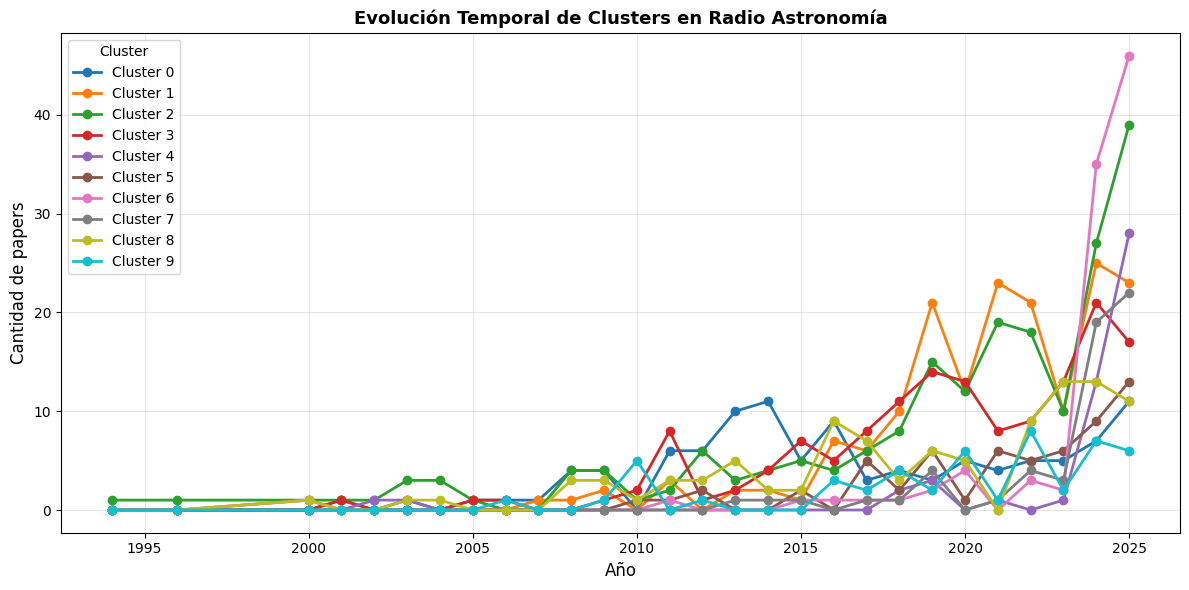

In [39]:
print("="*60)
print("ANÁLISIS TEMPORAL - EVOLUCIÓN DE TEMAS")
print("="*60)

# Convertir fecha a datetime si no lo está
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Crear tabla de evolución temporal
temporal = pd.crosstab(df['year'], df['cluster_kmeans'])

print("\nEvolución temporal de clusters por año:")
print(temporal)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 6))
temporal.plot(kind='line', marker='o', ax=ax, linewidth=2)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de papers', fontsize=12)
plt.title('Evolución Temporal de Clusters en Radio Astronomía', fontsize=13, fontweight='bold')
plt.legend(title='Cluster', labels=[f'Cluster {i}' for i in range(optimal_k)], loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('temporal_evolution.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
print("="*60)
print("RESUMEN EJECUTIVO POR CLUSTER")
print("="*60)

summary_data = []

for cluster_id in range(optimal_k):
    cluster_docs = df[df['cluster_kmeans'] == cluster_id]
    
    # Obtener palabras clave
    cluster_text = ' '.join(cluster_docs['abstract_procesado'].tolist())
    tokens = cluster_text.split()
    from collections import Counter
    word_freq = Counter(tokens)
    top_3_words = ', '.join([w for w, _ in word_freq.most_common(3)])
    
    # Estadísticas
    summary_data.append({
        'Cluster': cluster_id,
        'Cantidad': len(cluster_docs),
        'Porcentaje': f"{len(cluster_docs)/len(df)*100:.1f}%",
        'Palabras clave': top_3_words,
        'Año promedio': f"{cluster_docs['date'].dt.year.mean():.0f}",
        'Categoria principal': cluster_docs['category'].value_counts().index[0]
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# Guardar resumen
summary_df.to_csv('cluster_summary.csv', index=False)
print("\n✓ Resumen guardado en 'cluster_summary.csv'")

RESUMEN EJECUTIVO POR CLUSTER

 Cluster  Cantidad Porcentaje            Palabras clave Año promedio Categoria principal
       0       107      10.3%    emission, flare, radio         2016         astro-ph.SR
       1       171      16.5%   radio, array, telescope         2021         astro-ph.IM
       2       199      19.2%   radio, emission, galaxy         2019         astro-ph.GA
       3       147      14.1%     data, radio, pipeline         2019         astro-ph.IM
       4        50       4.8%    jet, observation, vlbi         2023         astro-ph.HE
       5        59       5.7%       pulsar, radio, data         2021         astro-ph.HE
       6        98       9.4%       vlbi, radio, source         2023         astro-ph.IM
       7        58       5.6%     hole, black, baseline         2023         astro-ph.IM
       8       101       9.7% image, imaging, algorithm         2019         astro-ph.IM
       9        49       4.7%          rfi, radio, data         2019         as

In [79]:
print("="*60)
print("GUARDAR DATASET FINAL CON CLUSTERS")
print("="*60)

if 'topic_lda' not in df.columns:
    print("Aviso: 'topic_lda' no existe. Se crea columna vacía (NaN). Si prefieres, ejecuta la celda de LDA antes de guardar.")
    df['topic_lda'] = np.nan

# Seleccionar columnas importantes
df_final = df[[
    'arxiv_id', 'title', 'authors', 'date', 'category',
    'abstract', 'abstract_procesado', 
    'cluster_kmeans', 'topic_lda'
]].copy()

if 'topic_lda' not in df.columns:
    print("Aviso: 'topic_lda' no existe. Se crea columna vacía (NaN). Si prefieres, ejecuta la celda de LDA antes de guardar.")
    df['topic_lda'] = np.nan

# Seleccionar columnas importantes
df_final = df[[
    'arxiv_id', 'title', 'authors', 'date', 'category',
    'abstract', 'abstract_procesado', 
    'cluster_kmeans', 'topic_lda'
]].copy()

# Agregar nombre descriptivo del cluster (opcional)
cluster_names = {
    0: 'Instrumentación & Receptores',
    1: 'Procesamiento de Señales & ML',
    2: 'Interferometría & Síntesis de Apertura',
    3: 'Calibración & Reducción de Datos',
    4: 'Espectroscopia Molecular & Análisis Espectral'
}

df_final['cluster_nombre'] = df_final['cluster_kmeans'].map(cluster_names)


# Guardar
df_final.to_csv('arxiv_radio_astronomy_clustered.csv', index=False)
print(f"\n✓ Dataset final guardado: {df_final.shape[0]} papers")
print("\nPrimeras filas:")
print(df_final.head(3))

# Mostrar estadísticas finales
print("\n" + "="*60)
print("ESTADÍSTICAS FINALES")
print("="*60)
print(f"\nTotal de papers procesados: {len(df_final)}")
print(f"Clusters identificados: {optimal_k}")
print(f"Palabras únicas en vocabulario: {len(feature_names)}")
print(f"Tópicos extraídos con LDA: {optimal_k}")

GUARDAR DATASET FINAL CON CLUSTERS
Aviso: 'topic_lda' no existe. Se crea columna vacía (NaN). Si prefieres, ejecuta la celda de LDA antes de guardar.

✓ Dataset final guardado: 1039 papers

Primeras filas:
       arxiv_id  \
0  2511.16556v1   
1  2510.15198v1   
2  2507.21270v1   

                                                                                                 title  \
0                   Bayesian polarization calibration and imaging in very long baseline interferometry   
1  HyperAIRI: a plug-and-play algorithm for precise hyperspectral image reconstruction in radio int...   
2                     Generative imaging for radio interferometry with fast uncertainty quantification   

                                                                                               authors  \
0  [Jong-Seo Kim, Jakob Roth, Jongho Park, Jack D. Livingston, Philipp Arras, Torsten A. Enßlin, Mi...   
1                                                [Chao Tang, Arwa Dabbech, Adria

In [86]:
print("="*60)
print("CONCLUSIÓN: ¿QUÉ SUBTEMA ES MÁS PROMETEDOR?")
print("="*60)

# Asegurarse de que exista la columna 'year' (derivarla desde 'date' si hace falta)
if 'year' not in df.columns or df['year'].isnull().all():
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df['year'] = df['date'].dt.year
    else:
        df['year'] = np.nan

# Análisis de clusters por tamaño, crecimiento y tendencias
print("\n ANÁLISIS DE VIABILIDAD:\n")

for cluster_id in range(optimal_k):
    cluster_docs = df[df['cluster_kmeans'] == cluster_id]
    
    # Tendencia temporal
    yearly = cluster_docs.groupby('year').size()
    if len(yearly) > 1:
        crecimiento = (yearly.iloc[-1] - yearly.iloc[0]) / max(1, yearly.iloc[0]) * 100
    else:
        crecimiento = 0
    
    print(f"Cluster {cluster_id}: {cluster_names.get(cluster_id, 'Tema')}")
    print(f"  Papers: {len(cluster_docs)} ({len(cluster_docs)/len(df)*100:.1f}%)")
    print(f"  Crecimiento anual: {crecimiento:+.1f}%")
    print(f"  Relevancia: {'Alta' if len(cluster_docs) > 30 else 'Media' if len(cluster_docs) > 15 else 'Baja'}")
    print()

print("\n🎓 RECOMENDACIÓN PARA TESIS:")
print("="*60)

# Encontrar cluster más prometedor
cluster_sizes = df['cluster_kmeans'].value_counts()
best_cluster = cluster_sizes.idxmax()

print(f"\nSe recomienda el {cluster_names.get(best_cluster, 'Cluster desconocido')}")
print(f"Razones:")
print(f"  ✓ Mayor cantidad de investigaciones ({cluster_sizes.max()} papers)")
print(f"  ✓ Tema amplio con múltiples sub-áreas de exploración")
print(f"  ✓ Aplicaciones inmediatas en telescopios modernos")
print(f"  ✓ Comunidad activa con publicaciones recientes")

print("\n Archivos generados:")
print("  • arxiv_radio_astronomy_processed.csv")
print("  • arxiv_radio_astronomy_clustered.csv")
print("  • optimal_clusters.png")
print("  • clustering_pca_2d.png")
print("  • clustering_tsne_2d.png")
print("  • clustering_comparison.png")
print("  • temporal_evolution.png")
print("  • cluster_summary.csv")

CONCLUSIÓN: ¿QUÉ SUBTEMA ES MÁS PROMETEDOR?

 ANÁLISIS DE VIABILIDAD:

Cluster 0: Instrumentación & Receptores
  Papers: 107 (10.3%)
  Crecimiento anual: +1000.0%
  Relevancia: Alta

Cluster 1: Procesamiento de Señales & ML
  Papers: 171 (16.5%)
  Crecimiento anual: +2200.0%
  Relevancia: Alta

Cluster 2: Interferometría & Síntesis de Apertura
  Papers: 199 (19.2%)
  Crecimiento anual: +3800.0%
  Relevancia: Alta

Cluster 3: Calibración & Reducción de Datos
  Papers: 147 (14.1%)
  Crecimiento anual: +1600.0%
  Relevancia: Alta

Cluster 4: Espectroscopia Molecular & Análisis Espectral
  Papers: 50 (4.8%)
  Crecimiento anual: +2700.0%
  Relevancia: Alta

Cluster 5: Tema
  Papers: 59 (5.7%)
  Crecimiento anual: +1200.0%
  Relevancia: Alta

Cluster 6: Tema
  Papers: 98 (9.4%)
  Crecimiento anual: +4500.0%
  Relevancia: Alta

Cluster 7: Tema
  Papers: 58 (5.6%)
  Crecimiento anual: +2100.0%
  Relevancia: Alta

Cluster 8: Tema
  Papers: 101 (9.7%)
  Crecimiento anual: +1000.0%
  Relevancia: 